# ML Assignment 2



## Classification Model Implementation

**Dataset:** Adult Income Dataset

**Objective:** Predict whether an individual's annual income exceeds \$50K using multiple machine learning classification algorithms.

## Step 1: Import Required Libraries

In this section, the required Python libraries for data manipulation, visualization, preprocessing, model building, and evaluation are imported.

In [136]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Step 2: Load the Dataset

The Adult Income dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [137]:
# Load dataset
df = pd.read_csv("../dataset/adult.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 3: Explore the Dataset

This section provides an overview of the dataset, including its dimensions, column names, data types, and sample records.

In [138]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Step 4: Check for Missing Values

The dataset is examined for missing values to determine whether any data cleaning is required before model training.

In [139]:
# Missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Step 5: Statistical Summary

Summary statistics are generated to understand the distribution of numerical features such as mean, standard deviation, minimum, and maximum values.

In [140]:
# Statistical summary
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Step 6: Target Variable Distribution

The distribution of the target variable (income) is visualized to understand the class balance in the dataset.

<Figure size 600x400 with 0 Axes>

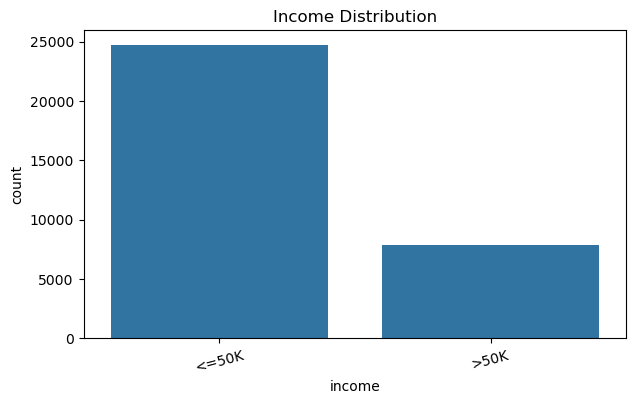

In [141]:
plt.figure(figsize=(6,4))

plt.figure(figsize=(7,4))

sns.countplot(x='income', data=df)

plt.title("Income Distribution")
plt.xticks(rotation=15)
plt.show()

## Step 7: Correlation Analysis

A correlation heatmap is generated to visualize relationships between numerical features.

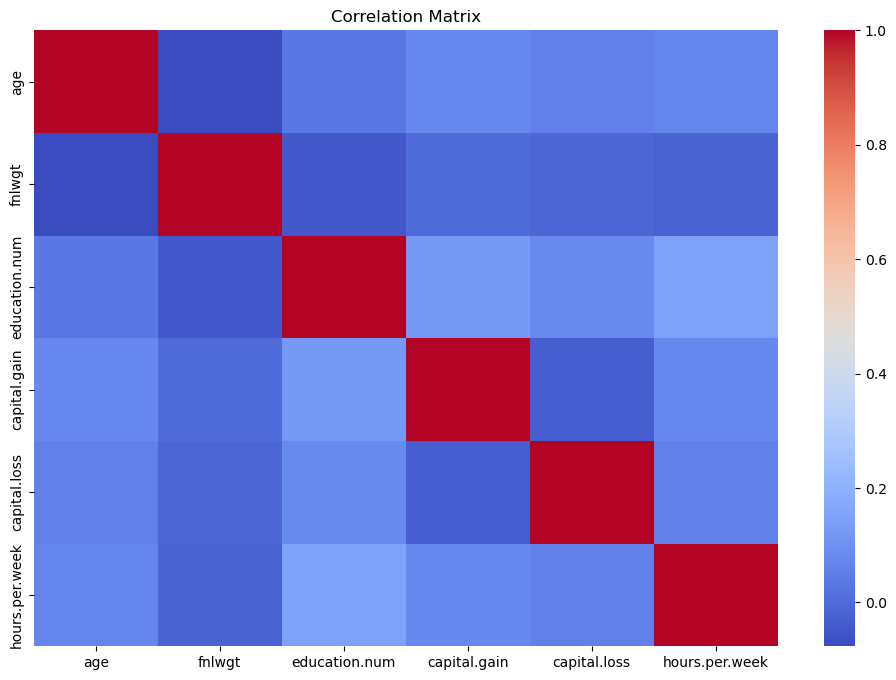

In [142]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Step 8: Duplicate Record Check

Duplicate records are identified and removed to improve data quality before model training.

In [143]:
# Check duplicate records
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("\nUpdated Dataset Shape:", df.shape)

Duplicate Records: 24

Updated Dataset Shape: (32537, 15)


## Step 9: Encode Categorical Variables

Machine learning algorithms require numerical input. Therefore, all categorical variables are converted into numerical values using Label Encoding.

In [144]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

print("Categorical features encoded successfully!")

df_encoded.head()

Categorical features encoded successfully!


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39,0
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39,0
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39,0
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39,0
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39,0


## Step 10: Feature and Target Separation

The dataset is divided into input features (X) and the target variable (y), which will be used for model training.

In [145]:
# ==========================================
# Split Features (X) and Target (y)
# ==========================================

# Features
X = df_encoded.drop("income", axis=1)

# Target
y = df_encoded["income"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)

X.head()

Feature Matrix Shape: (32537, 14)
Target Vector Shape : (32537,)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39


## Step 11: Train-Test Split

The dataset is split into training and testing sets using an 80:20 ratio. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [146]:
# ==========================================
# Split Dataset into Training and Testing Sets
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (26029, 14)
Testing Features  : (6508, 14)
Training Labels   : (26029,)
Testing Labels    : (6508,)


## Step 12: Feature Scaling

Feature scaling is performed using StandardScaler to standardize the feature values. This is particularly important for algorithms such as Logistic Regression and k-Nearest Neighbors.

# Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. The model is trained using the scaled training dataset.

In [147]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled Training Data Shape: (26029, 14)
Scaled Testing Data Shape : (6508, 14)


### Model Evaluation

The trained Logistic Regression model is evaluated using Accuracy, AUC Score, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC). A confusion matrix and classification report are also generated.

In [148]:
# ==========================================
# Import Evaluation Metrics
# ==========================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [149]:
# ==========================================
# Logistic Regression Model
# ==========================================

# Create model
log_model = LogisticRegression(random_state=42, max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [150]:
# ==========================================
# Logistic Regression Evaluation
# ==========================================

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("========== Logistic Regression ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")

# Store results for comparison
results = []

results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "AUC":auc,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "MCC":mcc
})

========== Logistic Regression ==========
Accuracy : 0.8239
AUC Score: 0.8497
Precision: 0.7140
Recall   : 0.4490
F1 Score : 0.5513
MCC Score: 0.4674


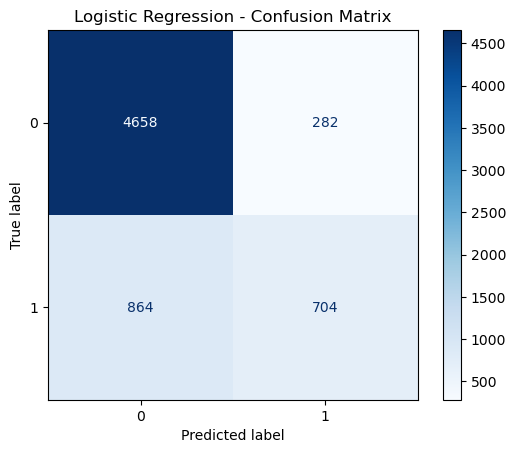

In [151]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [152]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred))
pd.DataFrame(results)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4940
           1       0.71      0.45      0.55      1568

    accuracy                           0.82      6508
   macro avg       0.78      0.70      0.72      6508
weighted avg       0.81      0.82      0.81      6508



,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.823909,0.849672,0.713996,0.44898,0.551292,0.467433


# Model 2: Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It recursively splits the dataset into subsets based on feature values to create a tree-like structure for decision-making.

The model is trained using the original (non-scaled) training dataset because Decision Trees do not require feature scaling.

In [153]:
# ==========================================
# Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


### Model Evaluation

The performance of the Decision Tree model is evaluated using Accuracy, AUC Score, Precision, Recall, F1 Score, Matthews Correlation Coefficient (MCC), Confusion Matrix, and Classification Report.

In [154]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

# Predict class labels
y_pred_dt = dt_model.predict(X_test)

# Predict probabilities
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_dt)
auc = roc_auc_score(y_test, y_prob_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
mcc = matthews_corrcoef(y_test, y_pred_dt)

print("========== Decision Tree ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")

# Save results
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "MCC": mcc
})

========== Decision Tree ==========
Accuracy : 0.8026
AUC Score: 0.7313
Precision: 0.5896
Recall   : 0.5938
F1 Score : 0.5917
MCC Score: 0.4615


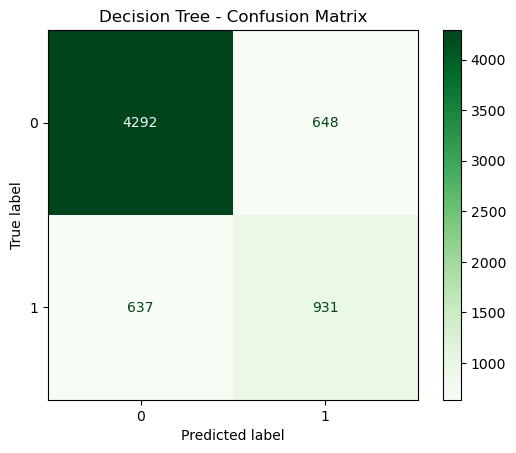

In [155]:
# ==========================================
# Decision Tree Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [156]:
# ==========================================
# Decision Tree Classification Report
# ==========================================

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4940
           1       0.59      0.59      0.59      1568

    accuracy                           0.80      6508
   macro avg       0.73      0.73      0.73      6508
weighted avg       0.80      0.80      0.80      6508



In [157]:
# ==========================================
# Comparison Table (So Far)
# ==========================================

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.823909,0.849672,0.713996,0.44898,0.551292,0.467433
1,Decision Tree,0.802551,0.731288,0.589614,0.59375,0.591675,0.461476


# Model 3: k-Nearest Neighbors (kNN)

The k-Nearest Neighbors (kNN) algorithm is a supervised learning algorithm that classifies a data point based on the majority class of its nearest neighbors. Since kNN relies on distance calculations, feature scaling is essential.

In [158]:
# ==========================================
# k-Nearest Neighbors (kNN)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")

kNN model trained successfully!


### Model Evaluation

The performance of the kNN model is evaluated using Accuracy, AUC Score, Precision, Recall, F1 Score, Matthews Correlation Coefficient (MCC), Confusion Matrix, and Classification Report.

In [159]:
# ==========================================
# kNN Evaluation
# ==========================================

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred_knn)
auc = roc_auc_score(y_test, y_prob_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
mcc = matthews_corrcoef(y_test, y_pred_knn)

print("========== kNN ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")

results.append({
    "Model":"k-Nearest Neighbors",
    "Accuracy":accuracy,
    "AUC":auc,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "MCC":mcc
})

========== kNN ==========
Accuracy : 0.8239
AUC Score: 0.8440
Precision: 0.6518
Recall   : 0.5778
F1 Score : 0.6126
MCC Score: 0.5007


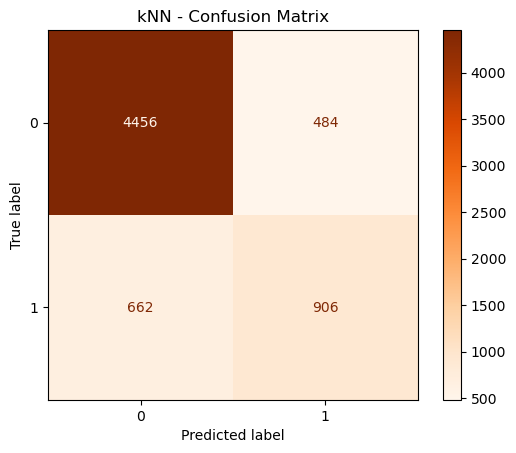

In [160]:
# ==========================================
# kNN Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn_model.classes_
)

disp.plot(cmap="Oranges")

plt.title("kNN - Confusion Matrix")
plt.show()

In [161]:
# ==========================================
# kNN Classification Report
# ==========================================

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89      4940
           1       0.65      0.58      0.61      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.74      0.75      6508
weighted avg       0.82      0.82      0.82      6508



In [162]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8239,0.8497,0.7140,0.4490,0.5513,0.4674
1,Decision Tree,0.8026,0.7313,0.5896,0.5938,0.5917,0.4615
2,k-Nearest Neighbors,0.8239,0.8440,0.6518,0.5778,0.6126,0.5007


# Model 4: Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem. It assumes that the predictor variables follow a Gaussian (normal) distribution and are conditionally independent given the target class.

The model is trained using the original (non-scaled) training dataset.

In [163]:
# ==========================================
# Gaussian Naive Bayes
# ==========================================

from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


### Model Evaluation

The Gaussian Naive Bayes model is evaluated using Accuracy, AUC Score, Precision, Recall, F1 Score, Matthews Correlation Coefficient (MCC), Confusion Matrix, and Classification Report.

In [164]:
# ==========================================
# Gaussian Naive Bayes Evaluation
# ==========================================

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_nb)
auc = roc_auc_score(y_test, y_prob_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
mcc = matthews_corrcoef(y_test, y_pred_nb)

print("========== Gaussian Naive Bayes ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")

results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "MCC": mcc
})

========== Gaussian Naive Bayes ==========
Accuracy : 0.7915
AUC Score: 0.8274
Precision: 0.6501
Recall   : 0.2915
F1 Score : 0.4025
MCC Score: 0.3329


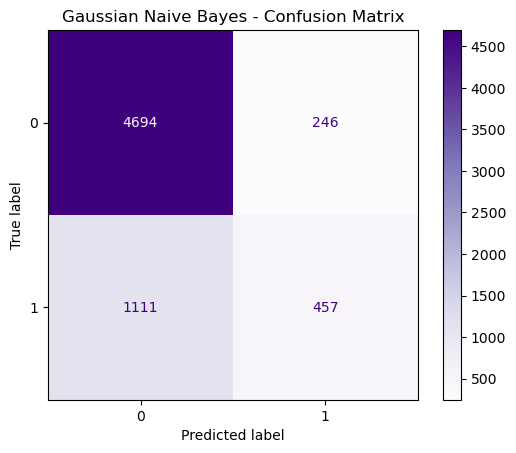

In [165]:
# ==========================================
# Naive Bayes Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap="Purples")

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

In [166]:
# ==========================================
# Naive Bayes Classification Report
# ==========================================

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.81      0.95      0.87      4940
           1       0.65      0.29      0.40      1568

    accuracy                           0.79      6508
   macro avg       0.73      0.62      0.64      6508
weighted avg       0.77      0.79      0.76      6508



In [167]:
results_df = pd.DataFrame(results).round(4)
results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8239,0.8497,0.7140,0.4490,0.5513,0.4674
1,Decision Tree,0.8026,0.7313,0.5896,0.5938,0.5917,0.4615
2,k-Nearest Neighbors,0.8239,0.8440,0.6518,0.5778,0.6126,0.5007
3,Naive Bayes,0.7915,0.8274,0.6501,0.2915,0.4025,0.3329


# Model 5: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. It generally provides better performance than a single Decision Tree by aggregating predictions from many trees.

In [168]:
# ==========================================
# Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Model Evaluation

The Random Forest model is evaluated using Accuracy, AUC Score, Precision, Recall, F1 Score, Matthews Correlation Coefficient (MCC), Confusion Matrix, and Classification Report.

In [169]:
# ==========================================
# Random Forest Evaluation
# ==========================================

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_prob_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
mcc = matthews_corrcoef(y_test, y_pred_rf)

print("========== Random Forest ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "MCC": mcc
})

========== Random Forest ==========
Accuracy : 0.8560
AUC Score: 0.8977
Precision: 0.7425
Recall   : 0.6161
F1 Score : 0.6734
MCC Score: 0.5863


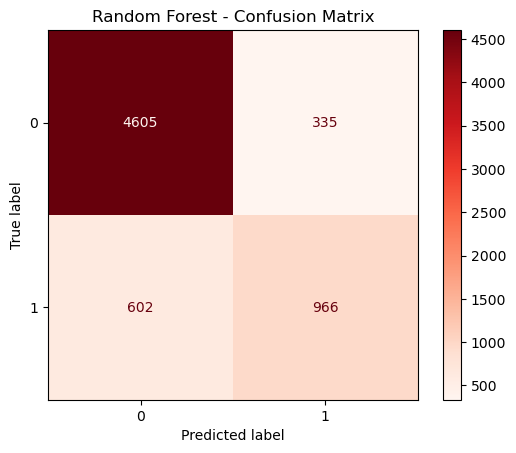

In [170]:
# ==========================================
# Random Forest Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Reds")

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [171]:
# ==========================================
# Random Forest Classification Report
# ==========================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4940
           1       0.74      0.62      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.77      0.79      6508
weighted avg       0.85      0.86      0.85      6508



In [172]:
# ==========================================
# Final Model Comparison
# ==========================================

results_df = pd.DataFrame(results).round(4)

results_df = results_df.sort_values(
    by=["Accuracy", "F1", "MCC"],
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Random Forest,0.8560,0.8977,0.7425,0.6161,0.6734,0.5863
1,k-Nearest Neighbors,0.8239,0.8440,0.6518,0.5778,0.6126,0.5007
2,Logistic Regression,0.8239,0.8497,0.7140,0.4490,0.5513,0.4674
3,Decision Tree,0.8026,0.7313,0.5896,0.5938,0.5917,0.4615
4,Naive Bayes,0.7915,0.8274,0.6501,0.2915,0.4025,0.3329


# Model Comparison

The performance of all five classification models is compared using six evaluation metrics:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

The comparison helps identify the best-performing model for the Adult Income dataset.

| Model                   | Observation                                                                                                                                                                                                 |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Logistic Regression** | Logistic Regression achieved good overall accuracy and the highest AUC among the linear models. However, its recall was relatively low, indicating that it missed a number of positive-class instances.     |
| **Decision Tree**       | Decision Tree provided better recall than Logistic Regression but had lower accuracy and AUC. The model may overfit the training data, affecting its generalization performance.                            |
| **k-Nearest Neighbors** | kNN achieved high accuracy and the best balance between precision and recall, resulting in a strong F1-score and MCC. Feature scaling contributed to its good performance.                                  |
| **Naive Bayes**         | Naive Bayes produced the lowest overall performance because its assumption of feature independence does not hold well for this dataset.                                                                     |
| **Random Forest**       | Random Forest achieved the highest Accuracy, AUC, Precision, Recall, F1-score, and MCC, making it the best-performing model. Its ensemble approach reduced overfitting and improved predictive performance. |
| **Overall Winner**      | **Random Forest** was the best-performing classifier for the Adult Income dataset, providing the highest overall predictive performance across most evaluation metrics.                                     |


# Step 13: Save Trained Models

The trained machine learning models are saved using the Joblib library. Saving trained models avoids retraining every time the Streamlit application runs and allows the models to be reused for prediction.

In [173]:
# ==========================================
# Save Trained Models
# ==========================================

import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save all trained models
joblib.dump(log_model, "../models/logistic_regression.pkl")
joblib.dump(dt_model, "../models/decision_tree.pkl")
joblib.dump(knn_model, "../models/knn.pkl")
joblib.dump(nb_model, "../models/naive_bayes.pkl")
joblib.dump(rf_model, "../models/random_forest.pkl")

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("All trained models saved successfully.")

All trained models saved successfully.


# Step 14: Export Test Dataset

The testing dataset is exported as a CSV file. This dataset can be used for validating predictions and testing the deployed Streamlit application.

In [174]:
# ==========================================
# Export Test Dataset
# ==========================================

test_data = X_test.copy()
test_data["income"] = y_test

test_data.to_csv("../dataset/test_data.csv", index=False)

print("test_data.csv exported successfully.")

test_data.csv exported successfully.


# Step 15: Save Encoded Dataset

The encoded dataset is saved for future reference. Since the machine learning models are trained on encoded numerical values, this dataset can be used for validation and future model enhancements.

In [175]:
# ==========================================
# Save Encoded Dataset
# ==========================================

df_encoded.to_csv("../dataset/adult_encoded.csv", index=False)

print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.


# Step 16: Feature Importance Analysis

Feature importance measures the contribution of each predictor variable in building the Random Forest model. Features with higher importance have a greater influence on the prediction.

           Feature  Importance
2           fnlwgt    0.166789
0              age    0.153213
10    capital.gain    0.117332
7     relationship    0.102012
4    education.num    0.088879
12  hours.per.week    0.082224
6       occupation    0.068741
5   marital.status    0.065973
1        workclass    0.039539
11    capital.loss    0.037155
3        education    0.032615
13  native.country    0.017053
8             race    0.014268
9              sex    0.014208


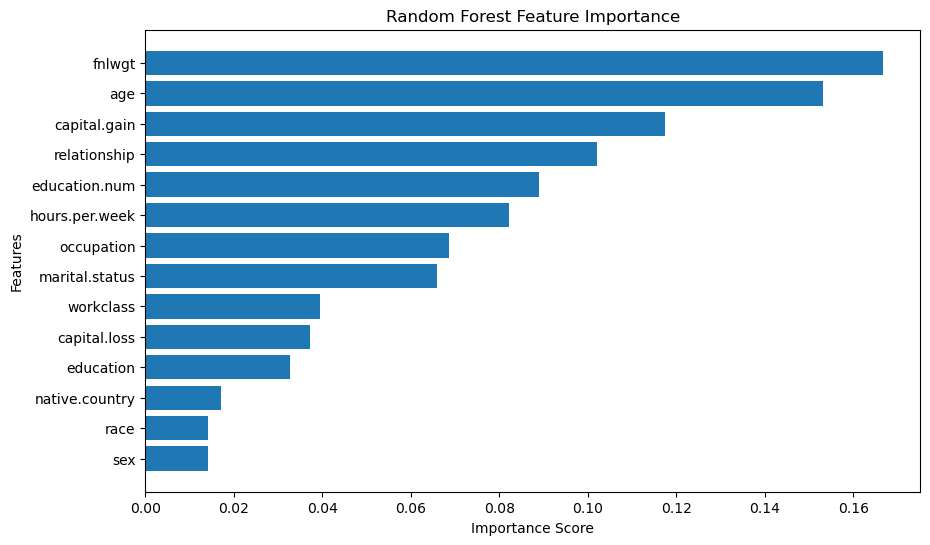

In [176]:
# ==========================================
# Feature Importance using Random Forest
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Step 17: Conclusion

Five machine learning classification algorithms were implemented and evaluated using the Adult Income dataset.

The models were compared using:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

Among all the models, **Random Forest** achieved the highest overall performance with an Accuracy of **85.60%**, AUC Score of **89.77%**, and the highest F1 Score and MCC.

Therefore, Random Forest is selected as the best-performing model for predicting income levels in this study.

# Best Performing Model

The best model is automatically identified based on the highest accuracy score.

In [177]:
# ==========================================
# Best Performing Model
# ==========================================

best_model = results_df.iloc[0]

print("Best Model")
print("-" * 40)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"AUC Score  : {best_model['AUC']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1']:.4f}")
print(f"MCC Score  : {best_model['MCC']:.4f}")

Best Model
----------------------------------------
Model Name : Random Forest
Accuracy   : 0.8560
AUC Score  : 0.8977
Precision  : 0.7425
Recall     : 0.6161
F1 Score   : 0.6734
MCC Score  : 0.5863
